In [1]:
pip install pandas numpy matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

# קריאת קובץ אקסל
df = pd.read_excel(r"C:\Users\USER\Desktop\לימודים\פרויקט גמר ב\סיוג חשבונות באינסטגרם - מאמר מחקר 1 נועה\איחוד דאטה סט.xlsx")

# הצגת 5 שורות ראשונות
df.head()


,numberOfFollowers,numberOfFollowing,nums/length username,hasDigitsInUsername,hasProfilePicture,descriptionLength,isPrivate,numberOfPosts,Following/Followers,Following/Posts,Followers/Posts,isFake,usernameDigitCount,usernameLength
0,488,604,0.33,1,1,30,1,35,1.237705,17.257143,13.942857,0,NaN,NaN
1,35,6,0.00,0,1,64,1,3,0.171429,2.000000,11.666667,0,NaN,NaN
2,328,668,0.00,0,1,82,1,319,2.036585,2.094044,1.028213,0,NaN,NaN
3,14890,7369,0.00,0,1,143,1,273,0.494896,26.992674,54.542125,0,NaN,NaN
4,225,356,0.50,1,1,76,1,6,1.582222,59.333333,37.500000,0,NaN,NaN


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score,recall_score, f1_score, roc_auc_score

In [5]:
X = df.drop(columns=['isFake','usernameDigitCount','usernameLength'])
y = df['isFake']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

#הורדנו את התכונה הנגזרת 
feature_columns = [
    'numberOfFollowers',
    'numberOfFollowing',
    'nums/length username',
    'hasDigitsInUsername',
    'hasProfilePicture',
    'descriptionLength',
    'isPrivate',
    'numberOfPosts',
    'Following/Posts',
    'Followers/Posts'
]

X_model = X[feature_columns]

X_train_sub = X_train[feature_columns]
X_test_sub = X_test[feature_columns]

rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 5,
    'random_state': 42,
    'n_jobs': -1
}
#בניית מודל 
model = RandomForestClassifier(**rf_params)

model.fit(X_train_sub, y_train);


Instagram Fake Account Detector ---



Number of followers:  5
Number of following:  766
Number of posts:  0
Number of digits in username:  4
Username length:  18
Has profile picture? (yes/no):  yes
Is the account private? (yes/no):  no
Bio length (characters):  40



--- Class probabilities ---
REAL (0): 25.93%
FAKE (1): 74.07%

Prediction Result: FAKE
Confidence Level: 74.07%

Calculating feature contributions...


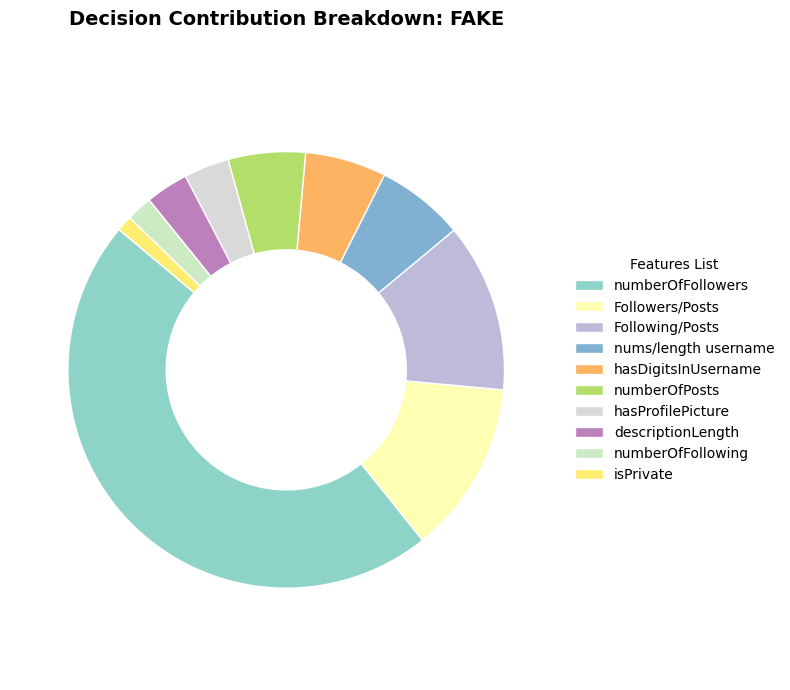


1. Most important feature: numberOfFollowers (46.9% of the decision)
2. Second most important feature: Followers/Posts (12.8% of the decision)


In [17]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

explainer = shap.TreeExplainer(model)

def predict_instagram_interactive_full(model, feature_columns):

    print("Instagram Fake Account Detector ---\n")

    num_followers = float(input("Number of followers: "))
    num_following = float(input("Number of following: "))
    num_posts = float(input("Number of posts: "))
    digit_in_username = float(input("Number of digits in username: "))
    username_length = float(input("Username length: "))

    has_profile_pic_raw = input(
        "Has profile picture? (yes/no): "
    ).strip().lower()

    is_private_raw = input(
        "Is the account private? (yes/no): "
    ).strip().lower()

    description_length = float(
        input("Bio length (characters): ")
    )

    nums_length_ratio = (
        digit_in_username / username_length
        if username_length else 0
    )

    has_digit_in_username = (
        1 if digit_in_username > 0 else 0
    )

    has_profile_pic = (
        1 if has_profile_pic_raw == "yes" else 0
    )

    is_private = (
        1 if is_private_raw == "yes" else 0
    )

    following_posts_ratio = (
        num_following / num_posts
        if num_posts else 0.0
    )

    followers_posts_ratio = (
        num_followers / num_posts
        if num_posts else 0.0
    )

    user_features = {
        'numberOfFollowers': num_followers,
        'numberOfFollowing': num_following,
        'nums/length username': nums_length_ratio,
        'hasDigitsInUsername': has_digit_in_username,
        'hasProfilePicture': has_profile_pic,
        'descriptionLength': description_length,
        'isPrivate': is_private,
        'numberOfPosts': num_posts,
        'Following/Posts': following_posts_ratio,
        'Followers/Posts': followers_posts_ratio
    }

    input_df = pd.DataFrame([user_features])

    input_df = input_df[feature_columns]# סידור הטבלה לפי סדר העמודות שהמודל האתאמן עליהן

    prediction = model.predict(input_df)[0]#מחזיר 0 או 1

    probabilities = model.predict_proba(input_df)[0]#החזרת הסתברות לכל מחלקה 

    print("\n--- Class probabilities ---")

    for cls, prob in zip(model.classes_, probabilities):

        label_name = (
            "REAL" if cls == 0 else "FAKE"
        )

        print(
            f"{label_name} ({cls}): "
            f"{prob*100:.2f}%"
        )

    confidence = probabilities[prediction] * 100 #שליפת ההסתברות הספציפית לפי הסיווג 

    label = "FAKE" if prediction == 1 else "REAL"

    print("\n==============================")

    print(f"Prediction Result: {label}")

    print(
        f"Confidence Level: "
        f"{confidence:.2f}%"
    )

    print("==============================")

    # SHAP Analysis
    print("\nCalculating feature contributions...")

    shap_values = explainer.shap_values(input_df) #כמה  כל פיצר תרגם לסיווג

    # בודקים איזה סוג נתונים בפועל קיבלנו, ומטפלים בכל מקרה בנפרד.ובסוף מחזיקים וקטור ערכים
    if isinstance(shap_values, list):
        current_values = shap_values[1][0]

    else:

        if len(shap_values.shape) == 3:
            current_values = shap_values[0, :, 1]

        else:
            current_values = shap_values[0]

    feature_impact = pd.Series(
        np.abs(current_values),
        index=feature_columns
    )

    feature_impact = feature_impact.sort_values(
        ascending=False
    )
#הצגת גרף עוגה
    if not feature_impact.empty:
        
#יצירת פלטת צבעים בהתאם לכמות הצבעים שנדרש 
        colors = plt.cm.Set3(
            np.linspace(
                0,
                1,
                len(feature_impact)
            )
        )

        fig, ax = plt.subplots(figsize=(8, 7))

        wedges, _ = ax.pie(
            feature_impact,
            startangle=140,
            colors=colors,
            wedgeprops=dict(
                width=0.45,
                edgecolor='w'
            )
        )

        ax.legend(
            wedges,
            feature_impact.index,
            title="Features List",
            loc="center left",
            bbox_to_anchor=(1, 0, 0.5, 1),
            frameon=False
        )

        plt.title(
            f"Decision Contribution Breakdown: {label}",
            fontsize=14,
            fontweight='bold',
            pad=25
        )

        ax.axis('equal')

        plt.tight_layout()

        plt.savefig(
            "shap_decision_breakdown.png",
            dpi=300,
            bbox_inches='tight'
        )

        plt.show()

        # =====================================
        # Most Important Features
        # =====================================

        total_impact = feature_impact.sum()

        if len(feature_impact) >= 2:

            pct_1 = (
                feature_impact.iloc[0]
                / total_impact
            ) * 100

            pct_2 = (
                feature_impact.iloc[1]
                / total_impact
            ) * 100

            print("\n" + "="*50)

            print(
                f"1. Most important feature: "
                f"{feature_impact.index[0]} "
                f"({pct_1:.1f}% of the decision)"
            )

            print(
                f"2. Second most important feature: "
                f"{feature_impact.index[1]} "
                f"({pct_2:.1f}% of the decision)"
            )

            print("="*50)

    return prediction, confidence


# =====================================
# Run
# =====================================
    
prediction, confidence = predict_instagram_interactive_full(
    model,
    feature_columns
)